<a href="https://colab.research.google.com/github/akhilboggiti-creator/Agentic-AI/blob/main/day_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# ■■ Feature Importance: Plot + Feature Selection ■■
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_diabetes # regression dataset repurposed as classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
import pandas as pd, numpy as np, matplotlib.pyplot as plt

In [4]:
# Use the diabetes (Pima Indians) dataset from before
import pandas as pd

# Download the dataset if it's not present
import os
if not os.path.exists('diabetes.csv'):
    !wget https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv
df = pd.read_csv('diabetes.csv')
fix_cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
for col in fix_cols: df[col] = df[col].replace(0, df[col].median())
X = df.drop('Outcome', axis=1)
y = df['Outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [5]:
# ■■ Feature importances ■■
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print('Feature Importances (higher = more important):')
print(imp.round(3))

Feature Importances (higher = more important):
Glucose                     0.259
BMI                         0.163
Age                         0.147
DiabetesPedigreeFunction    0.117
BloodPressure               0.088
Pregnancies                 0.078
Insulin                     0.076
SkinThickness               0.071
dtype: float64


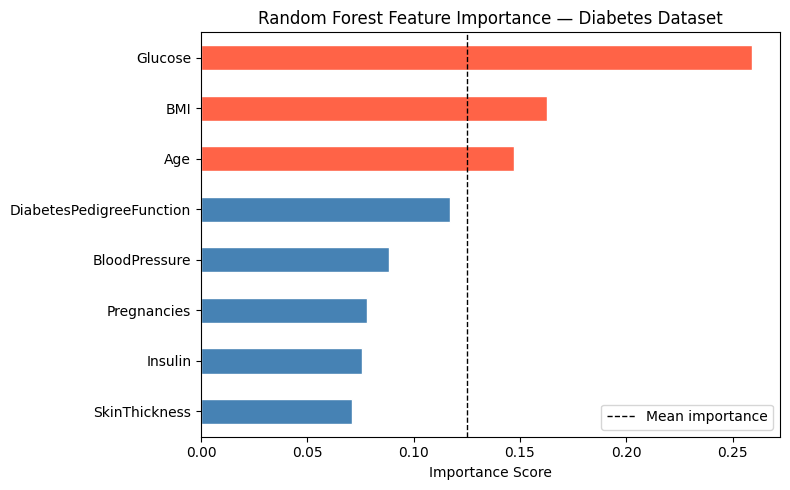

In [6]:
# ■■ Bar chart ■■
imp_sorted = imp.sort_values() # ascending for barh
colors = ['tomato' if v > imp.mean() else 'steelblue' for v in imp_sorted]
imp_sorted.plot(kind='barh', color=colors, figsize=(8,5), edgecolor='white')
plt.axvline(x=imp.mean(), color='black', linestyle='--', linewidth=1, label='Mean importance')
plt.title('Random Forest Feature Importance — Diabetes Dataset', fontsize=12)
plt.xlabel('Importance Score'); plt.legend(); plt.tight_layout(); plt.show()

In [7]:
# ■■ Feature Selection: keep only top features ■■
top_features = imp[imp > imp.mean()].index.tolist()
print(f'\nTop features (above average): {top_features}')
rf_top = RandomForestClassifier(n_estimators=200, random_state=42)
rf_top.fit(X_train[top_features], y_train)
full_acc = rf.score(X_test, y_test)
top_acc = rf_top.score(X_test[top_features], y_test)
print(f'Accuracy with all {len(X.columns)} features : {full_acc:.2%}')
print(f'Accuracy with top {len(top_features)} features : {top_acc:.2%}')
print('Often comparable — low-importance features can add noise!')


Top features (above average): ['Glucose', 'BMI', 'Age']
Accuracy with all 8 features : 77.27%
Accuracy with top 3 features : 72.73%
Often comparable — low-importance features can add noise!


 Review of the Code


This code uses a Random Forest Classifier to find the most important features in the Diabetes dataset and checks whether using only the important features gives similar accuracy.

#*Libraries Used:*

1. pandas (pd) – Used to load and manipulate the dataset.

2. numpy (np) – Used for numerical operations.

3. matplotlib.pyplot (plt) – Used to create the feature importance graph.


4. RandomForestClassifier – Machine Learning model used for classification and feature importance.

5. train_test_split – Used to split data into training and testing sets.


6. os – Used to check whether the dataset file exists.

#*Methods Used:*

1. pd.read_csv() – Reads the dataset from a CSV file.

2. replace() – Replaces invalid zero values with median values.

3. drop() – Removes the target column (Outcome) from features.


4. train_test_split() – Splits the dataset into training and testing data.

5. RandomForestClassifier() – Creates the Random Forest model.

6. fit() – Trains the model on the training data.

7. feature_importances_ – Returns the importance score of each feature.

8. sort_values() – Sorts features based on importance.

9. plot() – Creates a horizontal bar chart of feature importance.

10. score() – Calculates the model accuracy.

#*What the Code Does:*

↪ Loads the Diabetes dataset.

↪ Cleans the data by replacing zero values with median values.

↪ Splits the data into training and testing sets.

↪ Trains a Random Forest model.

↪ Calculates the importance of each feature.

↪ Displays feature importance using a bar chart.

↪ Selects only the features with above-average importance.

↪ Trains another model using only those top features.

↪ Compares the accuracy of both models.